In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
print(df.groupby('type')['director'].apply(lambda x: x.isna().sum()))

type
Movie       188
TV Show    2446
Name: director, dtype: int64


In [5]:
df[['rating','title']]

,rating,title
0,PG-13,Dick Johnson Is Dead
1,TV-MA,Blood & Water
2,TV-MA,Ganglands
3,TV-MA,Jailbirds New Orleans
4,TV-MA,Kota Factory
...,...,...
8802,R,Zodiac
8803,TV-Y7,Zombie Dumb
8804,R,Zombieland
8805,PG,Zoom


In [6]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [7]:
df_movies = df[df['type']=='Movie']
print(df_movies.shape)
df_movies.head()


(6131, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [8]:
df_movies['rating'].unique()

<StringArray>
[   'PG-13',       'PG',    'TV-MA',    'TV-PG',    'TV-14',     'TV-Y',
        'R',     'TV-G',    'TV-Y7',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

In [9]:
sups = df_movies[df_movies['rating'].str.contains(r'\bmin\b', na=False,regex=True)]
print(sups)

     show_id   type                                 title    director  \
5541   s5542  Movie                       Louis C.K. 2017  Louis C.K.   
5794   s5795  Movie                 Louis C.K.: Hilarious  Louis C.K.   
5813   s5814  Movie  Louis C.K.: Live at the Comedy Store  Louis C.K.   

            cast        country          date_added  release_year  rating  \
5541  Louis C.K.  United States       April 4, 2017          2017  74 min   
5794  Louis C.K.  United States  September 16, 2016          2010  84 min   
5813  Louis C.K.  United States     August 15, 2016          2015  66 min   

     duration listed_in                                        description  
5541      NaN    Movies  Louis C.K. muses on religion, eternal love, gi...  
5794      NaN    Movies  Emmy-winning comedy writer Louis C.K. brings h...  
5813      NaN    Movies  The comic puts his trademark hilarious/thought...  


In [10]:
mask = df_movies['rating'].str.contains('min',na=False)
df_movies.loc[mask, 'duration'] = df_movies.loc[mask,'rating']
df_movies.loc[mask,'rating'] = pd.NA

In [11]:
df_movies['rating'].unique()

<StringArray>
[   'PG-13',       'PG',    'TV-MA',    'TV-PG',    'TV-14',     'TV-Y',
        'R',     'TV-G',    'TV-Y7',        'G',    'NC-17',        nan,
       'NR', 'TV-Y7-FV',       'UR']
Length: 15, dtype: str

In [12]:
df_movies.info()

<class 'pandas.DataFrame'>
Index: 6131 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       6131 non-null   str  
 1   type          6131 non-null   str  
 2   title         6131 non-null   str  
 3   director      5943 non-null   str  
 4   cast          5656 non-null   str  
 5   country       5691 non-null   str  
 6   date_added    6131 non-null   str  
 7   release_year  6131 non-null   int64
 8   rating        6126 non-null   str  
 9   duration      6131 non-null   str  
 10  listed_in     6131 non-null   str  
 11  description   6131 non-null   str  
dtypes: int64(1), str(11)
memory usage: 622.7 KB


In [13]:
df_movies['director'] = df_movies['director'].fillna('Unknown')
df_movies['cast'] = df_movies['cast'].fillna('Unknowns')

df_movies['date_added'] = pd.to_datetime(df_movies['date_added'])

In [14]:
df_movies.info()

<class 'pandas.DataFrame'>
Index: 6131 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       6131 non-null   str           
 1   type          6131 non-null   str           
 2   title         6131 non-null   str           
 3   director      6131 non-null   str           
 4   cast          6131 non-null   str           
 5   country       5691 non-null   str           
 6   date_added    6131 non-null   datetime64[us]
 7   release_year  6131 non-null   int64         
 8   rating        6126 non-null   str           
 9   duration      6131 non-null   str           
 10  listed_in     6131 non-null   str           
 11  description   6131 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 622.7 KB


In [15]:
print(df_movies[df_movies['country'].isna()]['listed_in'].value_counts())

listed_in
Children & Family Movies                                         70
Stand-Up Comedy                                                  31
Dramas, International Movies                                     25
Movies                                                           23
Documentaries, International Movies                              21
                                                                 ..
Dramas, Thrillers                                                 1
Children & Family Movies, Documentaries, International Movies     1
Action & Adventure, Comedies, Independent Movies                  1
Comedies, Horror Movies, International Movies                     1
Comedies, Horror Movies, Sci-Fi & Fantasy                         1
Name: count, Length: 66, dtype: int64


In [16]:
#we parse date_added for year&month in another columns  after date_added
date_added_pos = df_movies.columns.get_loc('date_added')

df_movies.insert(date_added_pos+1, 'year_added', df_movies['date_added'].dt.year)
df_movies.insert(date_added_pos+1, 'month_added', df_movies['date_added'].dt.month)

In [17]:
df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknowns,United States,2021-09-25,9,2021,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [18]:
categories = df_movies['listed_in'].str.strip().str.split(', ').explode().unique()
categories

<StringArray>
[           'Documentaries', 'Children & Family Movies',
                   'Dramas',       'Independent Movies',
     'International Movies',                 'Comedies',
                'Thrillers',          'Romantic Movies',
         'Music & Musicals',            'Horror Movies',
         'Sci-Fi & Fantasy',       'Action & Adventure',
           'Classic Movies',           'Anime Features',
            'Sports Movies',              'Cult Movies',
     'Faith & Spirituality',             'LGBTQ Movies',
          'Stand-Up Comedy',                   'Movies']
Length: 20, dtype: str

In [19]:
categories_count = df_movies['listed_in'].str.strip().str.split(', ').explode().value_counts()
categories_count

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Anime Features                71
Cult Movies                   71
Faith & Spirituality          65
Movies                        57
Name: count, dtype: int64

In [20]:
df_movies.groupby('year_added').size()

year_added
2008       1
2009       2
2010       1
2011      13
2012       3
2013       6
2014      19
2015      56
2016     253
2017     839
2018    1237
2019    1424
2020    1284
2021     993
dtype: int64

In [21]:
date_realise_pos = df_movies.columns.get_loc('release_year')

df_movies.insert(date_realise_pos+1, 'delay_years', df_movies['year_added'] - df_movies['release_year'])

In [22]:
df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,delay_years,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknowns,United States,2021-09-25,9,2021,2020,1,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,28,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [23]:
categories_count.tail(10)

listed_in
Horror Movies           357
Stand-Up Comedy         343
Sci-Fi & Fantasy        243
Sports Movies           219
Classic Movies          116
LGBTQ Movies            102
Anime Features           71
Cult Movies              71
Faith & Spirituality     65
Movies                   57
Name: count, dtype: int64

In [24]:
top_counries = df_movies['country'].dropna().str.split(', ').explode().value_counts()
top_counries.head(10)

country
United States     2751
India              962
United Kingdom     532
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: count, dtype: int64

In [25]:
df_movies['duration_min'] = df_movies['duration'].str.extract(r'(\d+)').astype(float)
df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,delay_years,rating,duration,listed_in,description,duration_min
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknowns,United States,2021-09-25,9,2021,2020,1,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,28,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127.0


In [26]:
contigiensy = pd.crosstab(df_movies['listed_in'], df_movies['rating'])
contigiensy.head()

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
listed_in,,,,,,,,,,,,,,
Action & Adventure,0,0,0,0,23,86,2,0,17,0,0,0,0,0
"Action & Adventure, Anime Features",0,0,0,0,0,0,0,0,1,0,0,0,0,0
"Action & Adventure, Anime Features, Children & Family Movies",0,0,0,1,0,0,1,0,0,2,0,0,0,0
"Action & Adventure, Anime Features, Classic Movies",0,0,0,0,1,0,1,0,0,0,0,0,0,0
"Action & Adventure, Anime Features, Horror Movies",0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [27]:
chi2,p,dof,expected = chi2_contingency(contigiensy)
print(f'p-value {p:.4f}')

p-value 0.0000


In [28]:
exploded_cat = df_movies['listed_in'].str.split(', ').explode()

exploded = df_movies[['rating']].join(exploded_cat)

contigiensy = pd.crosstab(exploded['listed_in'].values, exploded['rating'].values)
print(contigiensy)
contigiensy.shape

col_0                      G  NC-17  NR   PG  PG-13    R  TV-14  TV-G  TV-MA  \
row_0                                                                          
Action & Adventure         1      0   9   32    148  220    213     0    201   
Anime Features             0      0   0    5      4    0     23     1     15   
Children & Family Movies  33      0   0  195     11    0     18    51      1   
Classic Movies             8      0   3   17     10   32     23     1     11   
Comedies                  11      2  14  148    168  180    465    29    431   
Cult Movies                0      0   3    4     13   37      7     0      5   
Documentaries              5      0  22   20     33   27    227    47    321   
Dramas                     6      1  27   69    192  375    693    27    830   
Faith & Spirituality       0      0   0   13      9    1     18     1      3   
Horror Movies              0      0   7    4     42   97     44     0    159   
Independent Movies         0      2  17 

(20, 14)

In [29]:
chi2, p, dof, expected = chi2_contingency(contigiensy)
print(f'p-value {p:.4f}')

p-value 0.0000


In [30]:
n = contigiensy.values.sum()

min_dim = min(contigiensy.shape)-1

cramers_v = np.sqrt(chi2/(n*min_dim))
print(f'Cramér\'s V: {cramers_v:.4f}')

Cramér's V: 0.2257


In [31]:
print('rating')
print(df_movies['rating'].value_counts())
print('Categories')
print(df_movies['listed_in'].str.split(', ').explode().value_counts().head(5))
print('Countries')
print(df_movies['country'].dropna().str.split(', ').explode().value_counts().head(5))

rating
rating
TV-MA       2062
TV-14       1427
R            797
TV-PG        540
PG-13        490
PG           287
TV-Y7        139
TV-Y         131
TV-G         126
NR            75
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64
Categories
listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64
Countries
country
United States     2751
India              962
United Kingdom     532
Canada             319
France             303
Name: count, dtype: int64


In [32]:
df_movies['primary_genre'] = df_movies['listed_in'].str.split(', ').str[0]
df_movies['primary_country'] = df_movies['country'].str.split(', ').str[0]
df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,delay_years,rating,duration,listed_in,description,duration_min,primary_genre,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknowns,United States,2021-09-25,9,2021,2020,1,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,Documentaries,United States
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,Children & Family Movies,NaN
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,28,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,Dramas,United States
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,Comedies,United States
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127.0,Dramas,Germany


In [33]:
def cramers_v(col1,col2):
    contigensy = pd.crosstab(col1,col2)
    chi2 = chi2_contingency(contigensy)[0]
    n = contigensy.values.sum()
    min_dim = min(contigensy.shape)-1
    return np.sqrt(chi2/(n*min_dim))

cols = ['rating', 'primary_genre', 'primary_country', 'type']
matrix = pd.DataFrame(index = cols, columns=cols, dtype=float)

for cols1 in cols:
    for cols2 in cols:
        matrix.loc[cols1,cols2] = cramers_v(df_movies[cols1].dropna(), df_movies[cols2].dropna())

print(matrix.round(3))

                 rating  primary_genre  primary_country  type
rating            1.000          0.260            0.207   NaN
primary_genre     0.260          1.000            0.191   NaN
primary_country   0.207          0.191            1.000   NaN
type                NaN            NaN              NaN   NaN


/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim))
/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim))
/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim))
/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim))
/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim))
/var/folders/bd/bb0lt1fx6sx34t0ngwfhdpq00000gp/T/ipykernel_1478/872872382.py:6: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(chi2/(n*min_dim)

In [34]:
rating_order = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'TV-G', 'PG', 'TV-PG', 'PG-13', 'TV-14', 'R', 'NC-17', 'TV-MA']

df_movies['rating_ordinal'] = df_movies['rating'].map({r: i for i, r in enumerate(rating_order)})

corr, p = spearmanr(df_movies['rating_ordinal'].dropna(), df_movies.loc[df_movies['rating_ordinal'].notna(), 'release_year'])

print(f'Spearman correlation: {corr:.3f}, p-value: {p:.4f}')

Spearman correlation: 0.164, p-value: 0.0000


In [35]:
df_movies.head()

,show_id,type,title,director,cast,country,date_added,month_added,year_added,release_year,delay_years,rating,duration,listed_in,description,duration_min,primary_genre,primary_country,rating_ordinal
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknowns,United States,2021-09-25,9,2021,2020,1,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,Documentaries,United States,7.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,9,2021,2021,0,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91.0,Children & Family Movies,NaN,5.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,9,2021,1993,28,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125.0,Dramas,United States,11.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,9,2021,2021,0,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104.0,Comedies,United States,7.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,9,2021,2021,0,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127.0,Dramas,Germany,11.0


In [36]:
corr, p = spearmanr(df_movies['rating_ordinal'].dropna(), df_movies.loc[df_movies['rating_ordinal'].notna(), 'duration_min'])
print(f'Spearman correlation: {corr:.3f}, p-value: {p:.4f}')

Spearman correlation: 0.049, p-value: 0.0001


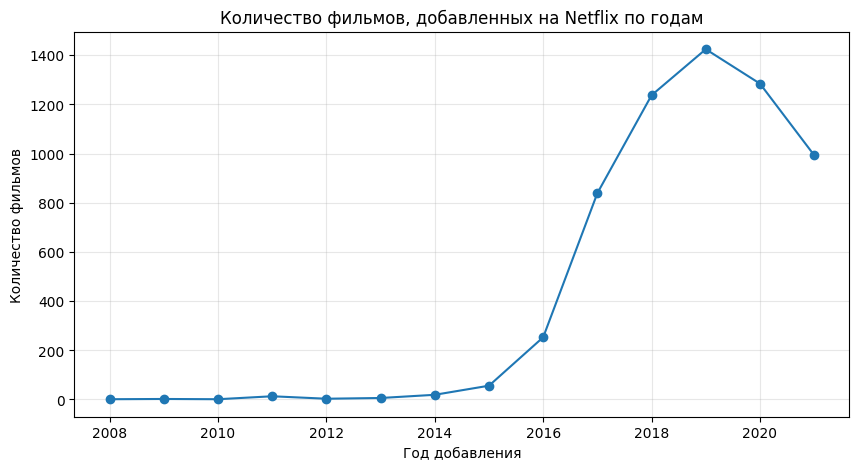

In [37]:
yearly_counts = df_movies.groupby('year_added').size()

plt.figure(figsize=(10,5))
plt.plot(yearly_counts.index, yearly_counts.values, marker = 'o')
plt.title('Количество фильмов, добавленных на Netflix по годам')
plt.xlabel('Год добавления')
plt.ylabel('Количество фильмов')
plt.grid(True, alpha=0.3)
plt.show()

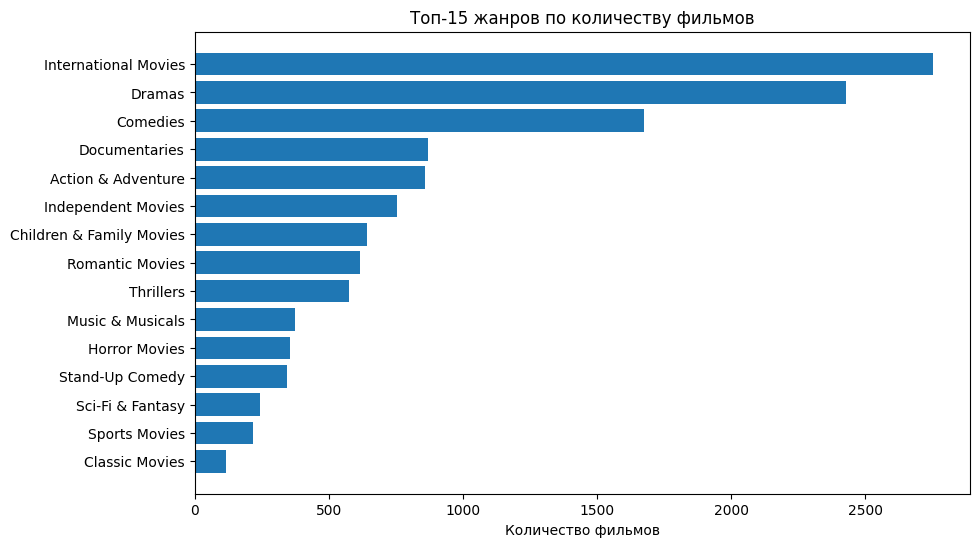

In [38]:
genre_counts = df_movies['listed_in'].str.split(', ').explode().value_counts().head(15)
plt.figure(figsize=(10, 6))
plt.barh(genre_counts.index[::-1], genre_counts.values[::-1])
plt.title('Топ-15 жанров по количеству фильмов')
plt.xlabel('Количество фильмов')
plt.show()

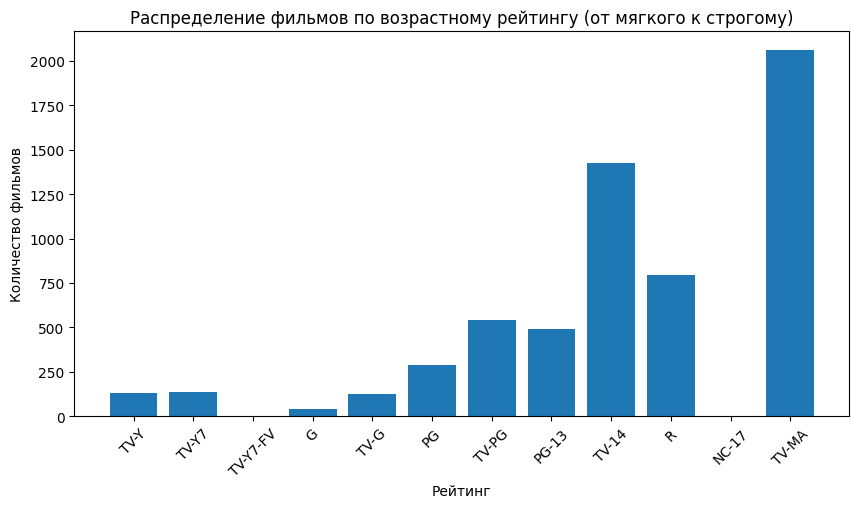

In [39]:
rating_order = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'G', 'TV-G', 'PG', 'TV-PG', 
                 'PG-13', 'TV-14', 'R', 'NC-17', 'TV-MA']

rating_counts_ordered = df_movies['rating'].value_counts().reindex(rating_order)

plt.figure(figsize=(10, 5))
plt.bar(rating_counts_ordered.index, rating_counts_ordered.values)
plt.title('Распределение фильмов по возрастному рейтингу (от мягкого к строгому)')
plt.xlabel('Рейтинг')
plt.ylabel('Количество фильмов')
plt.xticks(rotation=45)
plt.show()